# **EXPERIMENT-2**   - IRIS DATASET

**Step 1: Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

**Step 2: Load Dataset into a DataFrame**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/Iris_v2.csv")
df
print(df.head())#shows the first 5 rows

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ID   SL   SW   PL   PW Species
0   1  5.1  3.5  1.4  0.2  Setosa
1   2  4.9  3.0  1.4  0.2  Setosa
2   3  4.7  3.2  1.3  0.2  Setosa
3   4  4.6  3.1  1.5  0.2  Setosa
4   5  5.0  3.6  1.4  0.2  Setosa


**Step 3: Exploring Dataset**

In [ ]:
print("Shape of the dataset:",df.shape) #number of rows and columns.
print("Columns in the dataset:",df.columns) #names of all columns.

Shape of the dataset: (154, 6)
Columns in the dataset: Index(['ID', 'SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Step 4: Drop Unnecessary Columns**  

* Remove irrelevant columns (like “ID”) that don’t help prediction.



In [ ]:
df=df.drop(columns=["ID"])
print("Shape of the dataset after dropping a column:",df.shape)
print("Columns in the dataset after dropping:",df.columns)

Shape of the dataset after dropping a column: (154, 5)
Columns in the dataset after dropping: Index(['SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')


**Step 5: Handle Duplicates**




* Check for duplicate rows and remove them to avoid bias.





In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape of the dataset after removing duplicates:",df.shape)

Duplicate rows: 6
Shape of the dataset after removing duplicates: (148, 5)


**Step 6: Handle Missing Values**



*  .isna().sum() → counts missing values.
*  dropna() → removes rows with missing values.




In [ ]:
df.isna().sum()

,0
SL,7
SW,0
PL,2
PW,0
Species,0


In [ ]:
df1=df.dropna()
print("After handling thee missing values:",df1.shape)
df1.isna().sum()

After handling thee missing values: (139, 5)


,0
SL,0
SW,0
PL,0
PW,0
Species,0


**Step 7: Fill Missing Values**

* Instead of dropping, fill missing values with mean or median so the dataset stays complete.



In [ ]:
df2 = df.copy()
# Fill all numeric columns
df2 = df2.fillna(df2.mean(numeric_only=True))

In [ ]:
df2["SL"] = df2["SL"].fillna(df2["SL"].mean())#Handling missing values by filling them with the mean of the column
df2["SL"] = df2["SL"].fillna(df2["SL"].median())#median of he column
print("After handling the missing values:",df2.shape)
print(df2.isna().sum())


After handling the missing values: (148, 5)
SL         0
SW         0
PL         0
PW         0
Species    0
dtype: int64


**Step 8: Visualize Relationships**

*  Scatter plots show how features relate.



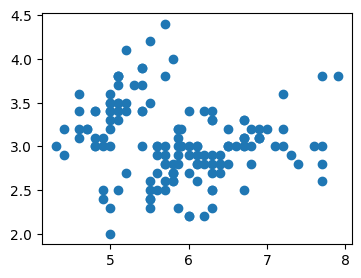

In [ ]:
plt.figure(figsize=(4,3))
plt.scatter(df2["SL"],df2["SW"])

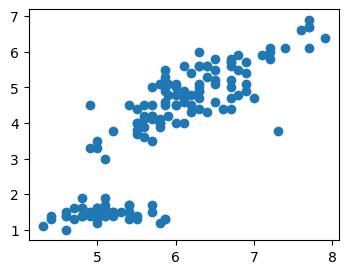

In [ ]:
plt.figure(figsize=(4,3))
plt.scatter(df2["SL"],df2["PL"])

**Step 9: Detect Outliers**

*  Boxen plots highlight outliers



<Axes: >

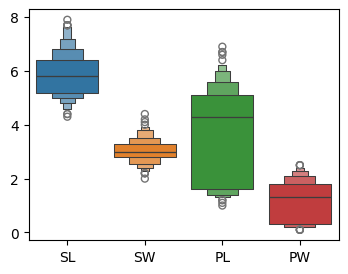

In [ ]:
plt.figure(figsize=(4,3))
sns.boxenplot(df2)

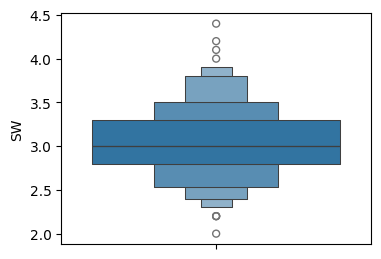

In [ ]:
plt.figure(figsize=(4,3))
sns.boxenplot(df2['SW'])
plt.show()     #we can roughly say that above 4 there is an chance of outlier

**Step 10: Remove Outliers**


*  Filter sepal width values less than 4 to reduce outliers.



In [ ]:
df.SW<4
df3=df2.loc[df.SW<4] # sw greater than 4 above values are outliers


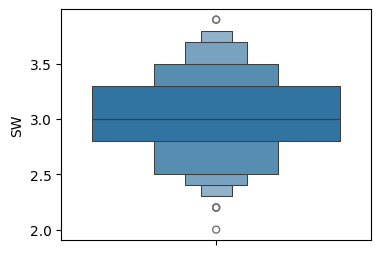

In [ ]:
plt.figure(figsize=(4,3))
sns.boxenplot(df3['SW'])
plt.show() #still there are 2 outliers but somehow we have deleted 2 . maybe the outliers are on 3.8 something

**Step 11: Check Unique Labels**

*   Shows the distinct species names in the dataset.



In [ ]:
df3.Species.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

**Step 12: Encode Labels (Manual)**

*  Replace species names with numbers manually.



In [ ]:
df4 = df3.copy()
df4.Species.replace({'Setosa':3, 'Versicolor':12, 'Virginica':8}, inplace=True)
df4.Species.unique()


/tmp/ipykernel_5343/3650440298.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df4.Species.replace({'Setosa':3, 'Versicolor':12, 'Virginica':8}, inplace=True)
/tmp/ipykernel_5343/3650440298.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4.Species.replace({'Setosa':3, 'Versicolor':12, 'Vir

array([ 3, 12,  8])

**Step 13: Encode Labels (LabelEncoder)**

*  LabelEncoder automatically converts species names into integers (0,1,2).
* .fit() → teaches the model using training data.



In [ ]:
df5 = df3.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df5["Species"] = le.fit_transform(df5["Species"])
print(df5["Species"] )


0      0
1      0
2      0
3      0
4      0
      ..
148    2
149    2
150    2
151    2
152    2
Name: Species, Length: 144, dtype: int64


**Step 14: Encode Labels (OneHotEncoder)**

*  Definition: OneHotEncoder converts species into binary columns (Setosa=100, Versicolor=010, Virginica=001).
Also separates features (X) and labels (Y).



In [ ]:
enc = preprocessing.OneHotEncoder()
X, Y = df3.iloc[:,0:-1], df3[["Species"]]
Y_trans = enc.fit_transform(Y)
print(Y_trans.toarray()[:10])


[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


**Step 15: Train-Test Split (Whole DataFrame)**


*   Splitting the dataset into training (70%) and testing (30%) sets.



In [ ]:
train_df,test_df=train_test_split(df5,train_size=0.7) #or test_size=0.3
print("Shape:",train_df.shape)
print(train_df.head())

Shape: (100, 5)
     SL   SW   PL   PW  Species
59  4.9  2.4  3.3  1.0        1
66  5.6  2.9  3.6  1.3        1
3   4.6  3.1  1.5  0.2        0
93  6.1  3.0  4.6  1.4        1
31  4.8  3.1  1.6  0.2        0


**Step 16: Train-Test Split (Features & Labels)**

*  Split features (X) and labels (Y) into training and testing sets.
*   stratify=Y → ensures that the class distribution (Setosa, Versicolor, Virginica) is preserved in both training and testing sets. of all three species.
*   random_state=3 → ensures reproducibility.







In [ ]:
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.3)
train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=3)
print(train_x.head())#the first few rows of training features (like sepal length, sepal width, petal length, petal width).
print(train_y.head())# the first few rows of training labels (species corresponding to those feature rows).



           SL   SW   PL   PW
11   4.800000  3.4  1.6  0.2
143  6.700000  3.1  5.6  2.4
41   5.100000  3.4  1.5  0.2
86   5.400000  3.0  4.5  1.5
124  5.860993  2.8  4.9  2.0
        Species
11       Setosa
143   Virginica
41       Setosa
86   Versicolor
124   Virginica


**Step 17: Min-Max Scaling**
* It converts values into range 0 to 1
  *  **X scaled​=​ X − Xmin​​ / Xmax ​− Xmin**
* Helps model learn better (especially when features have different ranges)
* ✔ fit() → learns min & max from training data
 ✔ transform() → applies same scaling to test data
  * Prevents data leakage

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler object
scaler = MinMaxScaler()

# Fit only on training data, transform both
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

# Convert back to DataFrame (optional but neat for output)
train_x_scaled = pd.DataFrame(train_x_scaled, columns=train_x.columns)
test_x_scaled = pd.DataFrame(test_x_scaled, columns=test_x.columns)

# Print small output
print("Scaled Train Data (first 5 rows):")
print(train_x_scaled.head())

print("Scaled Test Data (first 5 rows):")
print(test_x_scaled.head())

Scaled Train Data (first 5 rows):
         SL        SW        PL        PW
0  0.138889  0.705882  0.089286  0.041667
1  0.666667  0.529412  0.803571  0.958333
2  0.222222  0.705882  0.071429  0.041667
3  0.305556  0.470588  0.607143  0.583333
4  0.433609  0.352941  0.678571  0.791667
Scaled Test Data (first 5 rows):
         SL        SW        PL        PW
0  0.416667  0.294118  0.500000  0.458333
1  0.722222  0.529412  0.767857  0.833333
2  0.666667  0.470588  0.732143  0.916667
3  0.388889  0.411765  0.553571  0.500000
4  0.305556  0.882353  0.071429  0.041667


In [ ]:
print("Min values:\n", train_x_scaled.min())
print("Max values:\n", train_x_scaled.max())

Min values:
 SL    0.0
SW    0.0
PL    0.0
PW    0.0
dtype: float64
Max values:
 SL    1.0
SW    1.0
PL    1.0
PW    1.0
dtype: float64


In [ ]:
#model creation , trainig model and making predictions
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(train_x_scaled, train_y.values.ravel())
predictions = model.predict(test_x_scaled)

print("Predictions (first 5):")
print(predictions[:5])

from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(test_y, predictions)
print("Accuracy:", accuracy)
cm = confusion_matrix(test_y, predictions)
print(cm)


Predictions (first 5):
['Versicolor' 'Virginica' 'Virginica' 'Versicolor' 'Setosa']
Accuracy: 0.8863636363636364
[[14  0  0]
 [ 0 12  3]
 [ 0  2 13]]
